# Kütüphaneler ve verinin yüklenmesi

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from keras.utils import to_categorical

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from scipy.stats import pearsonr




In [2]:
data = pd.read_csv('/content/Crop_recommendation.csv.xls')

# Keşifsel Veri Analizi (EDA)


In [3]:
data.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [5]:
data.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


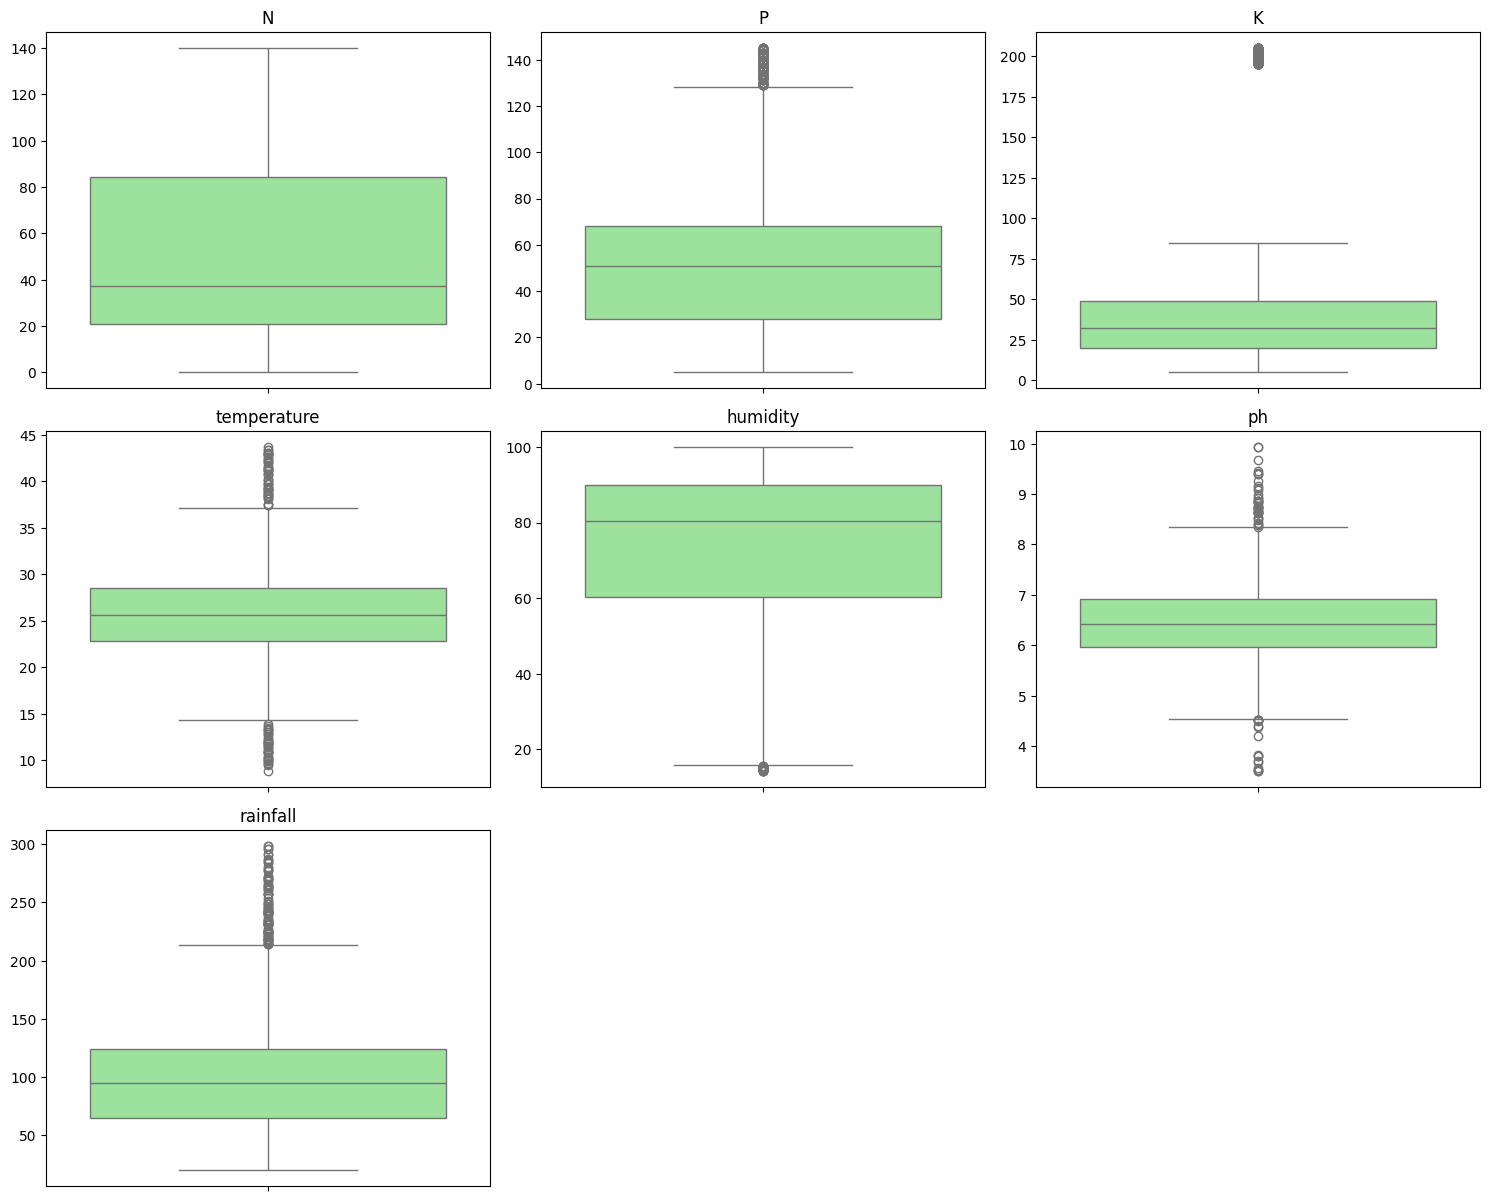

In [6]:
numerical_cols = data.select_dtypes(include=np.number).columns
n_cols = len(numerical_cols)

n_rows = (n_cols + 2)
n_cols_per_row = 3

fig, axes = plt.subplots(n_rows, n_cols_per_row, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=data[col], ax=axes[i], color="lightgreen")
    axes[i].set_title(col)
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [7]:
Q1 = data["P"].quantile(0.25)
Q3 = data["P"].quantile(0.75)
IQR = Q3 - Q1

alt_sinir = Q1 - 1.5 * IQR
ust_sinir = Q3 + 1.5 * IQR

aykiri_degerler = data[(data["P"] < alt_sinir) | (data["P"] > ust_sinir)]

print(aykiri_degerler)

       N    P    K  temperature   humidity        ph    rainfall   label
1200  24  130  195    29.996772  81.541566  6.112306   67.125345  grapes
1201  13  144  204    30.728040  82.426141  6.092242   68.381355  grapes
1204  24  131  196    22.032962  83.743728  5.732454   65.344408  grapes
1206  35  140  197    16.775573  82.752419  6.106191   66.762855  grapes
1209  17  134  204    39.040720  80.183933  6.499605   73.884670  grapes
...   ..  ...  ...          ...        ...       ...         ...     ...
1594  35  145  195    22.039115  94.580758  6.231950  110.980401   apple
1596  25  132  198    22.319441  90.851744  5.732758  100.117344   apple
1597  31  137  196    22.144641  93.825674  6.400321  120.631078   apple
1598  36  144  196    23.651676  94.505288  6.496934  115.361127   apple
1599  10  140  197    22.169395  90.271856  6.229499  124.468311   apple

[138 rows x 8 columns]


In [8]:

for col in numerical_cols:
  Q1 = data[col].quantile(0.25)
  Q3 = data[col].quantile(0.75)
  IQR = Q3 - Q1

  alt_sinir = Q1 - 1.5 * IQR
  ust_sinir = Q3 + 1.5 * IQR

  data[col] = np.where(data[col] < alt_sinir, alt_sinir, data[col])
  data[col] = np.where(data[col] > ust_sinir, ust_sinir, data[col])

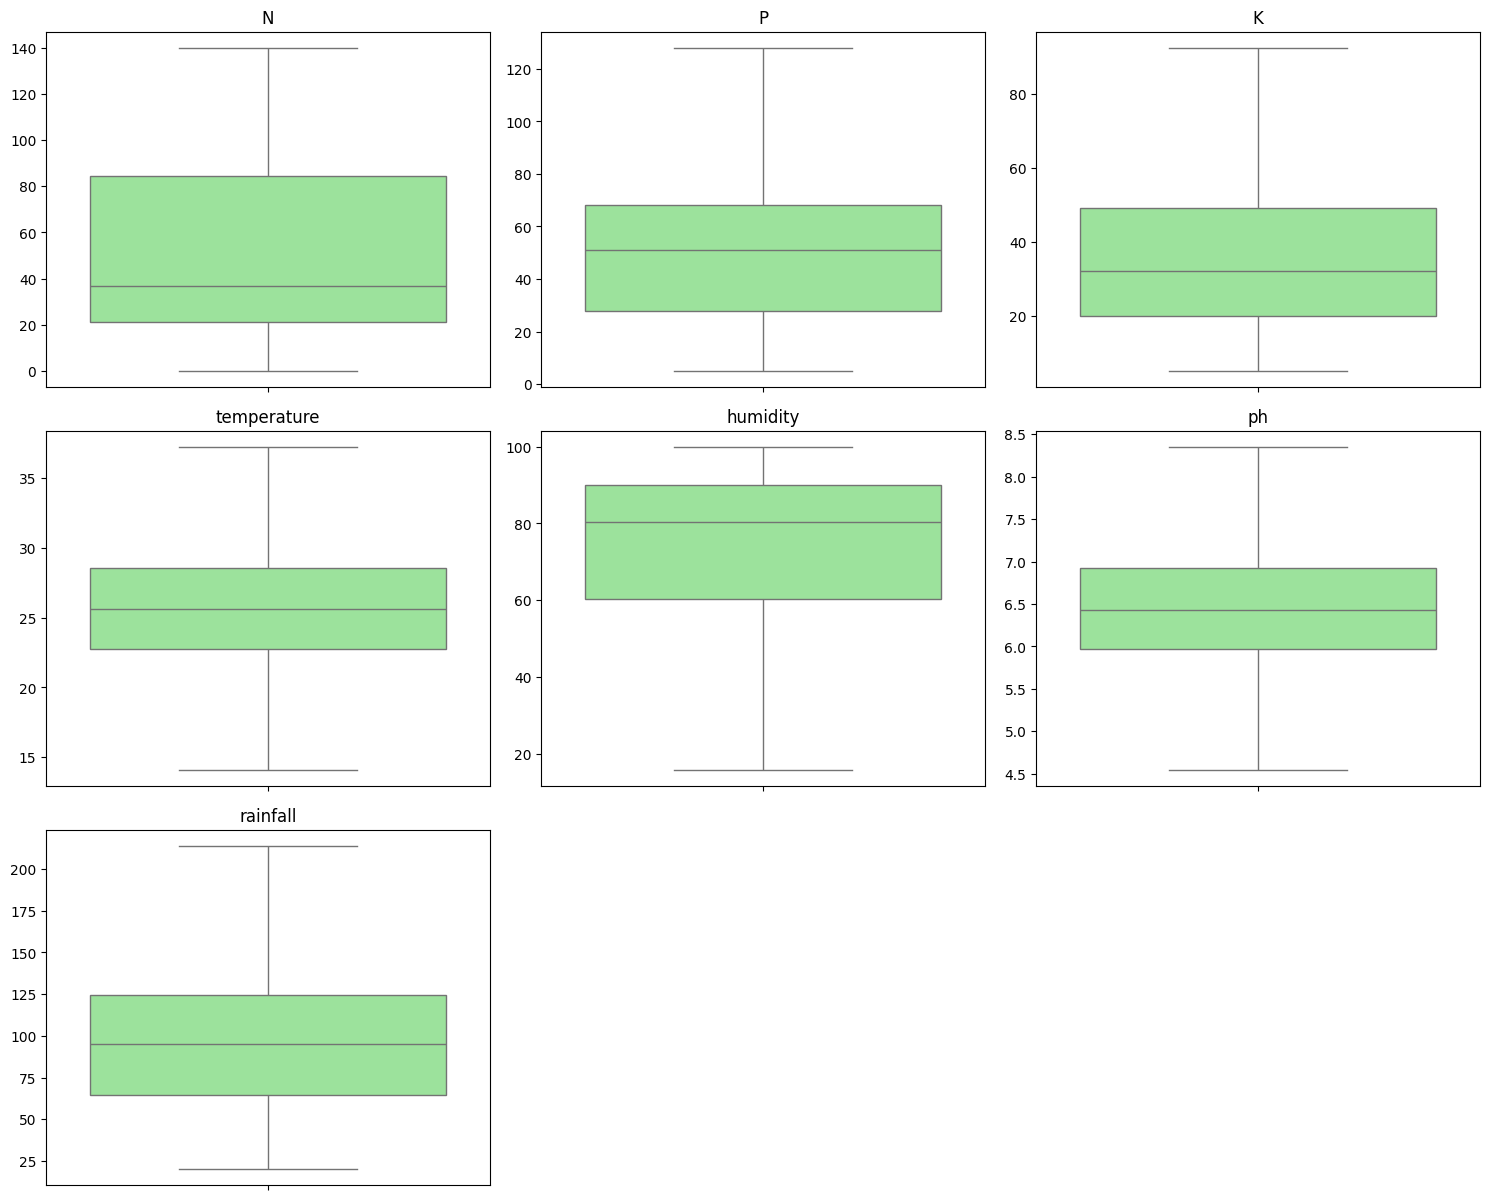

In [9]:
fig, axes = plt.subplots(n_rows, n_cols_per_row, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=data[col], ax=axes[i], color="lightgreen")
    axes[i].set_title(col)
    axes[i].set_ylabel('') # Remove y-label to avoid clutter

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [10]:
r_matrix = data[numerical_cols].corr()
p_matrix = data[numerical_cols].corr(method=lambda x, y: pearsonr(x, y)[1])

annot_matrix = r_matrix.round(2).astype(str) + "\n(p=" + p_matrix.round(3).astype(str) + ")"

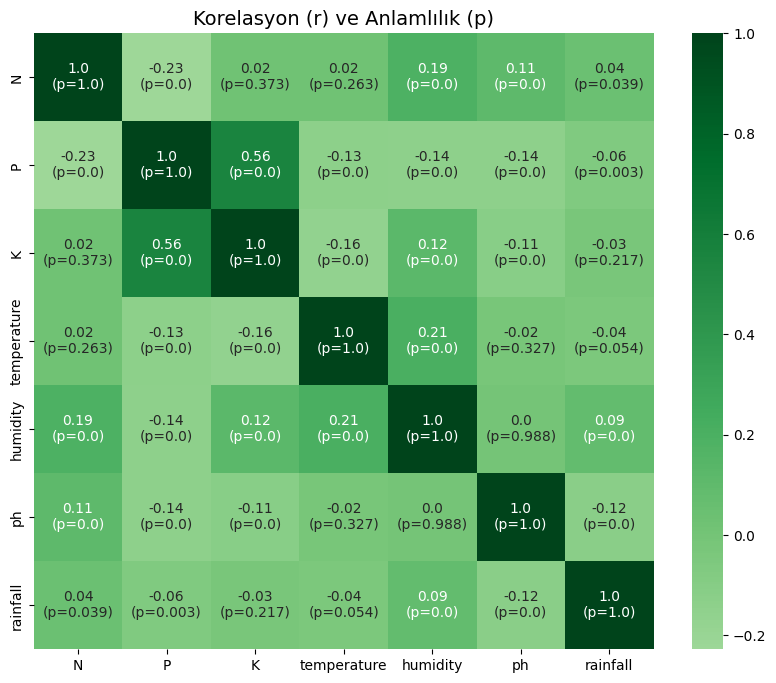

In [11]:
# korelasyon
plt.figure(figsize=(10, 8))
sns.heatmap(r_matrix, annot=annot_matrix, fmt="", cmap='Greens', center=0)
plt.title("Korelasyon (r) ve Anlamlılık (p)", fontsize=14)
plt.show()

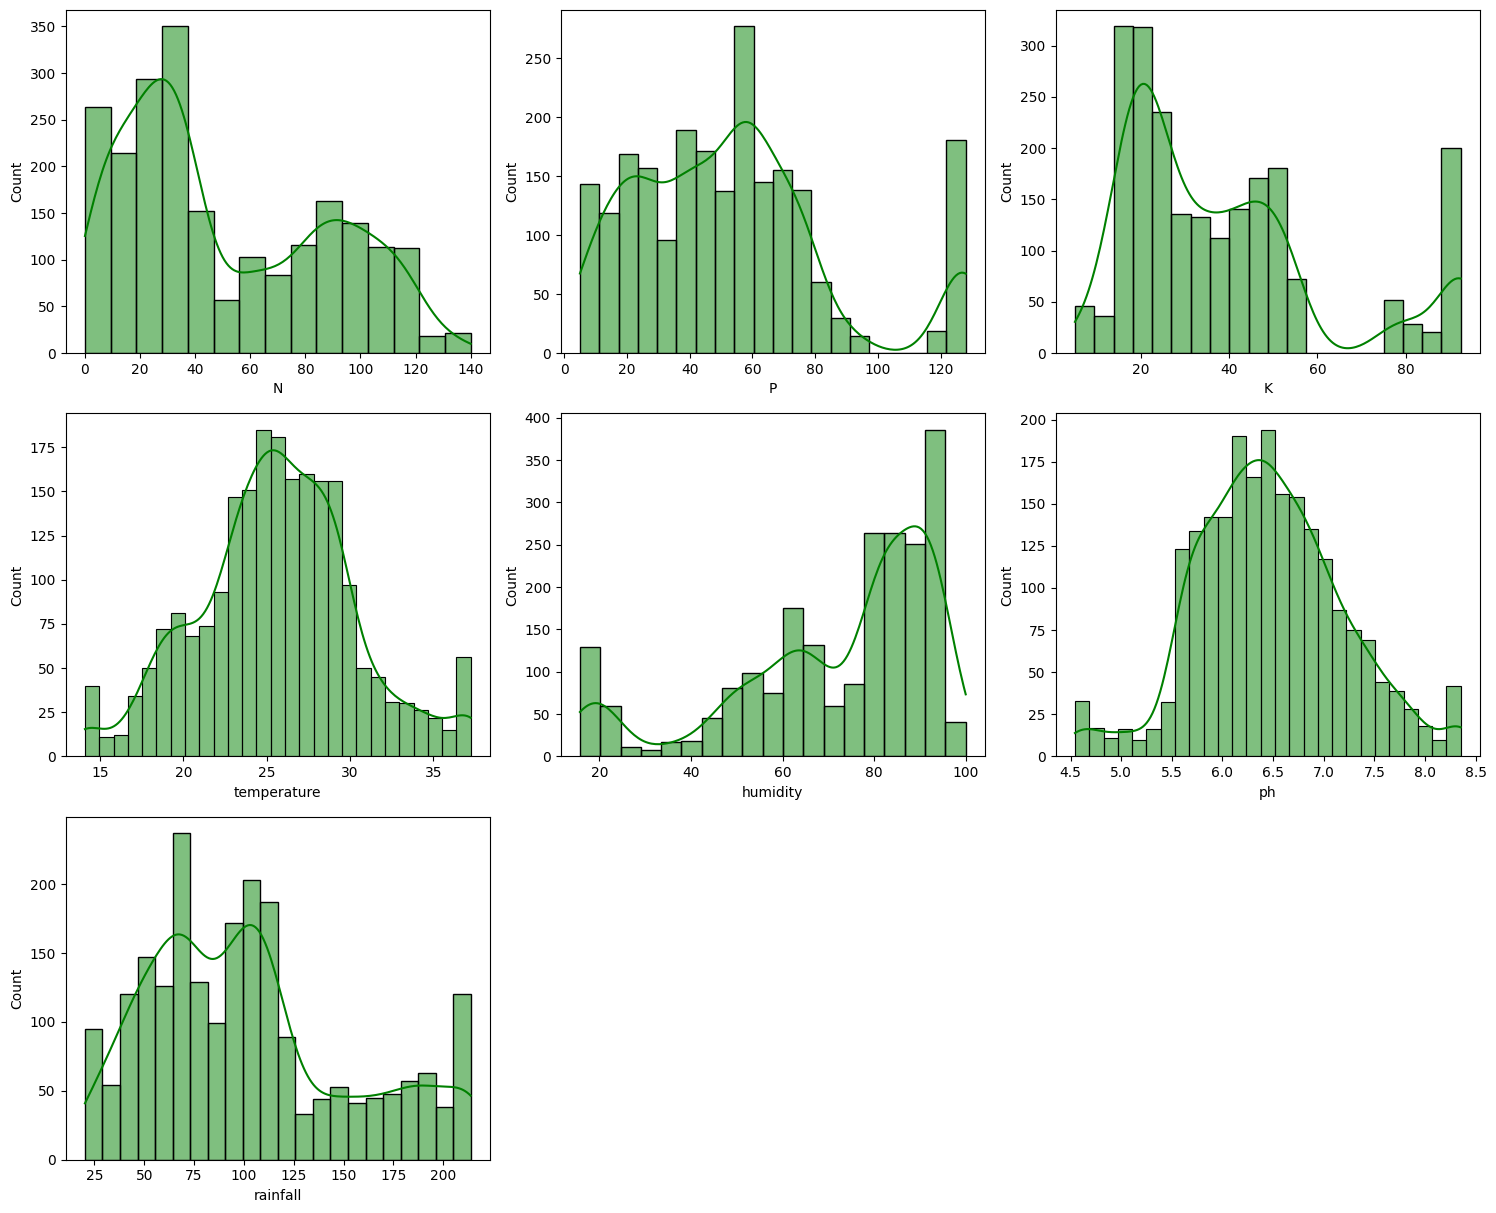

In [12]:
# dağılımlar

fig, axes = plt.subplots(n_rows, n_cols_per_row, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(data[col], ax=axes[i],kde = True, color="green", edgecolor = "black")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

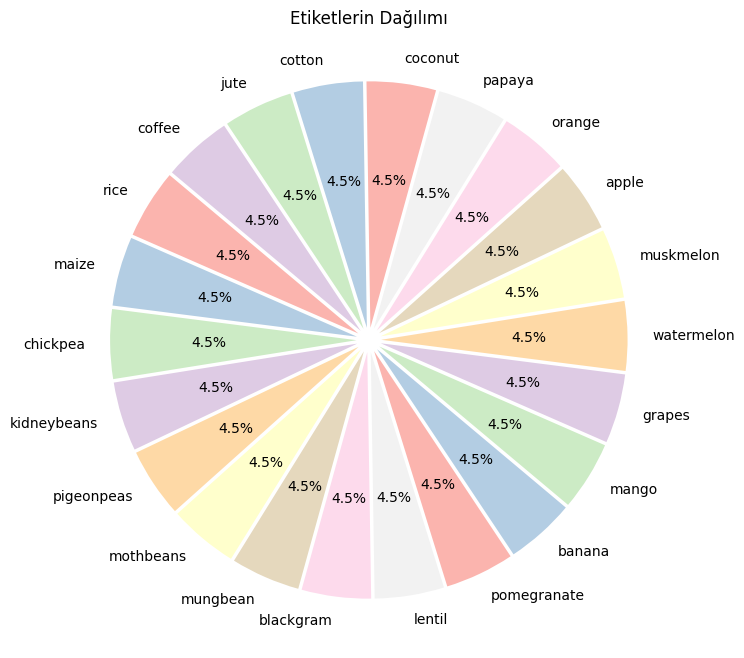

In [13]:
counts = data['label'].value_counts()

# Grafik oluşturma
plt.figure(figsize=(8, 8))
plt.pie(counts,
        labels = counts.index,
        autopct = '%1.1f%%',
        startangle = 140,
        colors = plt.cm.Pastel1.colors,
        explode = [0.05] * len(counts))

plt.title('Etiketlerin Dağılımı')
plt.show()

In [14]:
data.duplicated().sum()

np.int64(0)

# Model Eğitimi

## Holdout

In [15]:
X = data.drop('label', axis=1)
y = data['label']

# 1. Hedef Değişkeni Sayısallaştırma
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 2. Eğitim ve Test Seti Bölme
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# 3. Ölçeklendirme
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
print("x train shape=", X_train.shape)
print("y train shape=", y_train.shape)
print("x test shape=", X_test.shape)
print("y test shape=", y_test.shape)

x train shape= (1760, 7)
y train shape= (1760,)
x test shape= (440, 7)
y test shape= (440,)


In [17]:
# Mimari
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(22, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Erken durdurma
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# EĞİTİM
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stop],
    verbose=0
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


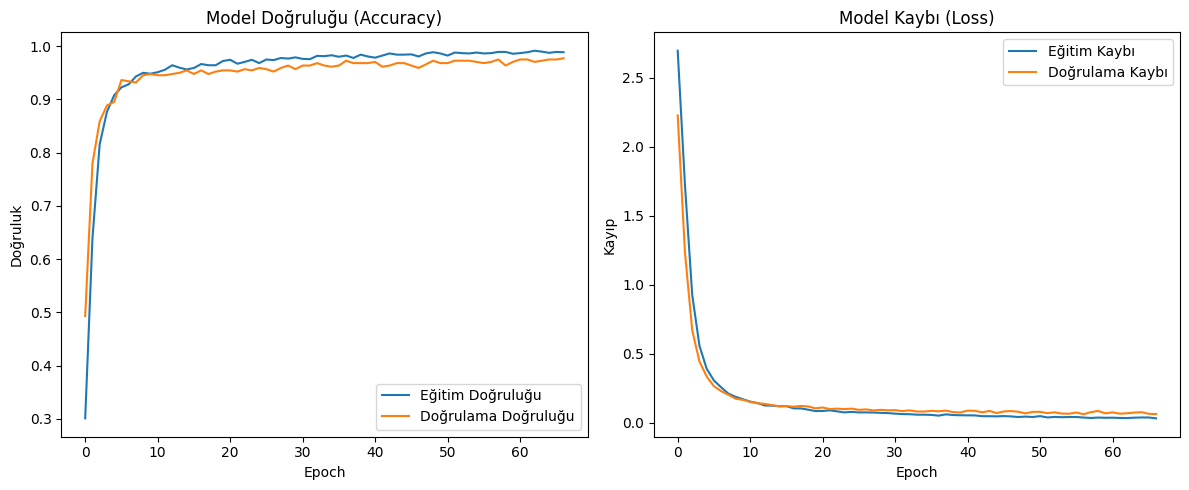

In [18]:
# Grafiklerin hazırlanması
plt.figure(figsize=(12, 5))

# 1. Doğruluk (Accuracy) Grafiği
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu')
plt.plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu')
plt.title('Model Doğruluğu (Accuracy)')
plt.xlabel('Epoch')
plt.ylabel('Doğruluk')
plt.legend()

# 2. Kayıp (Loss) Grafiği
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.title('Model Kaybı (Loss)')
plt.xlabel('Epoch')
plt.ylabel('Kayıp')
plt.legend()

plt.tight_layout()
plt.show()

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


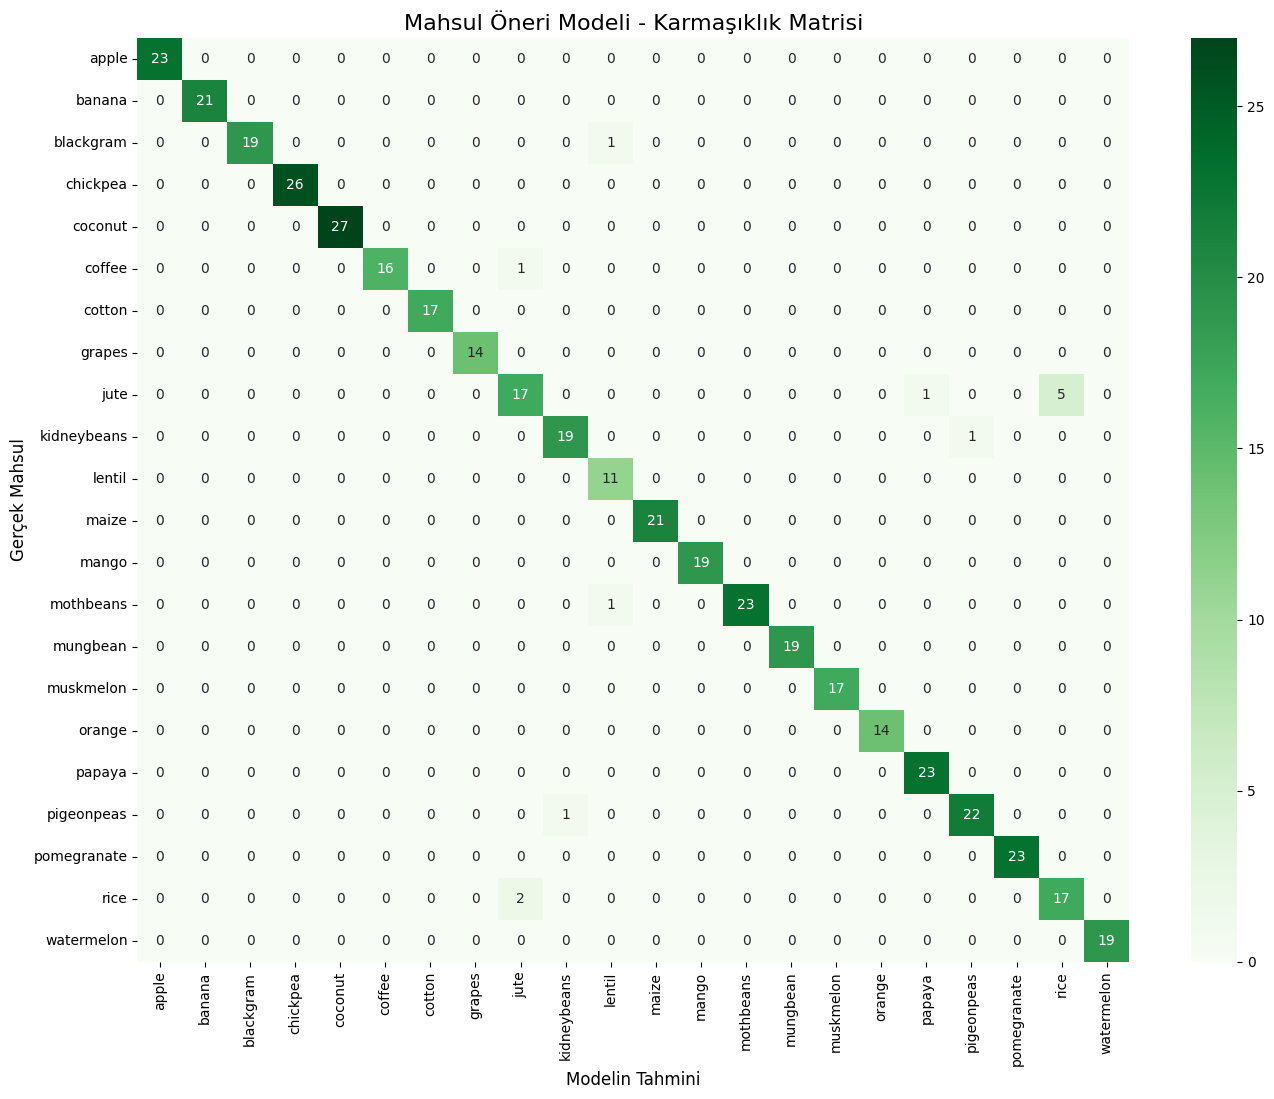


--- SINIFLANDIRMA RAPORU ---

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      0.94      0.97        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.85      0.74      0.79        23
 kidneybeans       0.95      0.95      0.95        20
      lentil       0.85      1.00      0.92        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.96      0.98        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00       

In [19]:
y_pred_probs = model.predict(X_test_scaled)

# 2. En yüksek olasılıklı sınıfın indeksini seç (Sayısal sınıfa dönüştür)
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. Confusion Matrix (Karışıklık Matrisi) Oluşturma
cm = confusion_matrix(y_test, y_pred)

# 4. Görselleştirme
plt.figure(figsize=(16, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title('Mahsul Öneri Modeli - Karmaşıklık Matrisi', fontsize=16)
plt.xlabel('Modelin Tahmini', fontsize=12)
plt.ylabel('Gerçek Mahsul', fontsize=12)
plt.show()

# 5. Detaylı Performans Raporu (Precision, Recall, F1)
print("\n--- SINIFLANDIRMA RAPORU ---\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

## K-Fold Cross Validation




In [20]:
from sklearn.model_selection import KFold


X_full = data.drop('label', axis=1)
y_full = data['label']


le = LabelEncoder()
y_encoded_full = le.fit_transform(y_full)


n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)


kfold_accuracy = []
kfold_loss = []
all_histories_kfold = []

print(f"Starting {n_splits}-Fold Cross-Validation...")

for fold, (train_index, val_index) in enumerate(kf.split(X_full, y_encoded_full)):
    print(f"\n--- Fold {fold + 1}/{n_splits} ---")


    X_train_fold, X_val_fold = X_full.iloc[train_index], X_full.iloc[val_index]
    y_train_fold, y_val_fold = y_encoded_full[train_index], y_encoded_full[val_index]


    scaler_fold = StandardScaler()
    X_train_scaled_fold = scaler_fold.fit_transform(X_train_fold)
    X_val_scaled_fold = scaler_fold.transform(X_val_fold)


    model_kfold = Sequential([
        Dense(128, activation='relu', input_shape=(X_train_scaled_fold.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(22, activation='softmax')
    ])

    model_kfold.compile(optimizer='adam',
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

    early_stop_kfold = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


    history_kfold = model_kfold.fit(
        X_train_scaled_fold, y_train_fold,
        epochs=100,
        batch_size=32,
        validation_data=(X_val_scaled_fold, y_val_fold),
        callbacks=[early_stop_kfold],
        verbose=0
    )
    all_histories_kfold.append(history_kfold)


    loss_fold, accuracy_fold = model_kfold.evaluate(X_val_scaled_fold, y_val_fold, verbose=0)
    kfold_loss.append(loss_fold)
    kfold_accuracy.append(accuracy_fold)

    print(f"Fold {fold + 1} - Validation Accuracy: {accuracy_fold:.4f}, Validation Loss: {loss_fold:.4f}")

print("\n--- K-Fold Cross-Validation Complete ---")
print(f"Average K-Fold Validation Accuracy: {np.mean(kfold_accuracy):.4f} (+/- {np.std(kfold_accuracy):.4f})")
print(f"Average K-Fold Validation Loss: {np.mean(kfold_loss):.4f} (+/- {np.std(kfold_loss):.4f})")

Starting 5-Fold Cross-Validation...

--- Fold 1/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1 - Validation Accuracy: 0.9841, Validation Loss: 0.0524

--- Fold 2/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 2 - Validation Accuracy: 0.9818, Validation Loss: 0.0400

--- Fold 3/5 ---


...

Fold 3 - Validation Accuracy: 0.9955, Validation Loss: 0.0220

--- Fold 4/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 4 - Validation Accuracy: 0.9955, Validation Loss: 0.0154

--- Fold 5/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 5 - Validation Accuracy: 0.9886, Validation Loss: 0.0416

--- K-Fold Cross-Validation Complete ---
Average K-Fold Validation Accuracy: 0.9891 (+/- 0.0056)
Average K-Fold Validation Loss: 0.0343 (+/- 0.0136)



--- K-FOLD MODELİ İÇİN KARMAŞIKLIK MATRİSİ ---
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


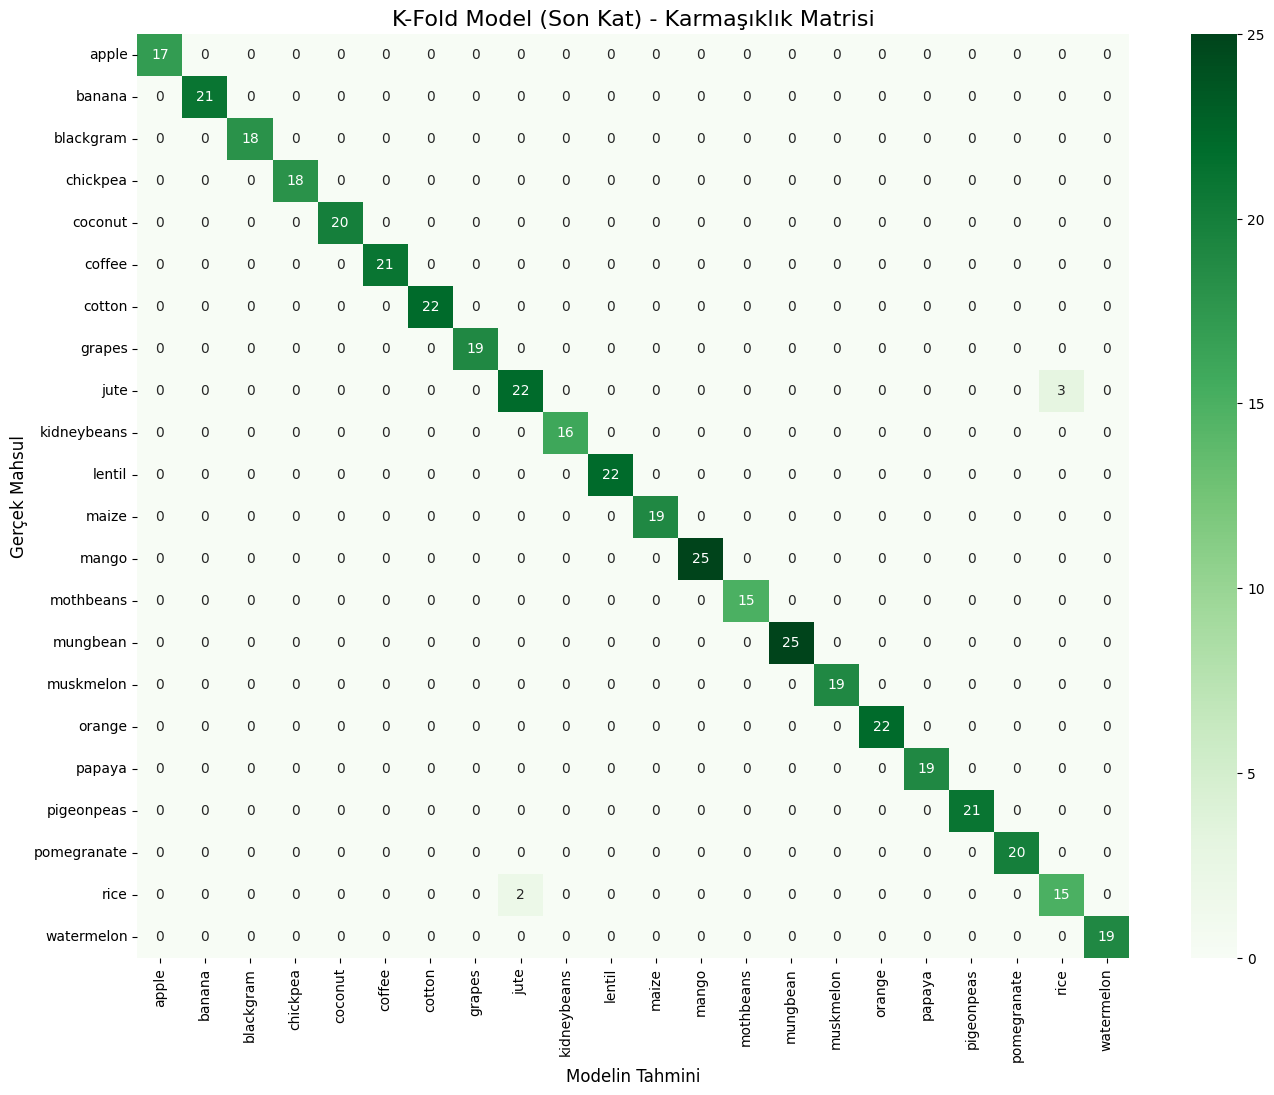


--- K-FOLD MODELİ İÇİN SINIFLANDIRMA RAPORU (SON KAT) ---
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        17
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        18
    chickpea       1.00      1.00      1.00        18
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        21
      cotton       1.00      1.00      1.00        22
      grapes       1.00      1.00      1.00        19
        jute       0.92      0.88      0.90        25
 kidneybeans       1.00      1.00      1.00        16
      lentil       1.00      1.00      1.00        22
       maize       1.00      1.00      1.00        19
       mango       1.00      1.00      1.00        25
   mothbeans       1.00      1.00      1.00        15
    mungbean       1.00      1.00      1.00        25
   muskmelon       1.00      1.00      1.00        19
      orange       1.0

In [21]:
print("\n--- K-FOLD MODELİ İÇİN KARMAŞIKLIK MATRİSİ ---")

y_pred_probs_kfold = model_kfold.predict(X_val_scaled_fold)
y_pred_kfold = np.argmax(y_pred_probs_kfold, axis=1)

cm_kfold = confusion_matrix(y_val_fold, y_pred_kfold)

plt.figure(figsize=(16, 12))
sns.heatmap(cm_kfold, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title('K-Fold Model (Son Kat) - Karmaşıklık Matrisi', fontsize=16)
plt.xlabel('Modelin Tahmini', fontsize=12)
plt.ylabel('Gerçek Mahsul', fontsize=12)
plt.show()

print("\n--- K-FOLD MODELİ İÇİN SINIFLANDIRMA RAPORU (SON KAT) ---")
print(classification_report(y_val_fold, y_pred_kfold, target_names=le.classes_))


--- K-FOLD MODELİ İÇİN KAYIP VE DOĞRULUK GRAFİKLERİ (TÜM KATLAR) ---


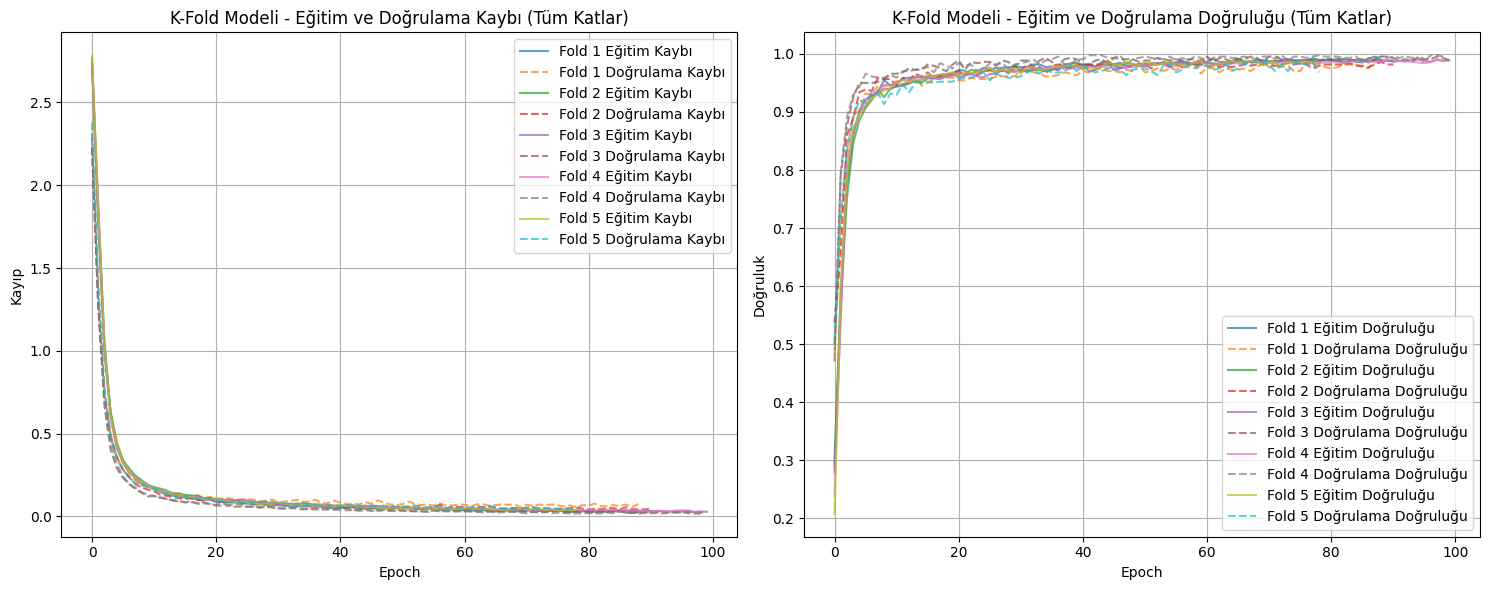

In [22]:
print("\n--- K-FOLD MODELİ İÇİN KAYIP VE DOĞRULUK GRAFİKLERİ (TÜM KATLAR) ---")

plt.figure(figsize=(15, 6))

# Kayıp Grafiği
plt.subplot(1, 2, 1)
for i, history in enumerate(all_histories_kfold):
    plt.plot(history.history['loss'], label=f'Fold {i+1} Eğitim Kaybı', alpha=0.7)
    plt.plot(history.history['val_loss'], label=f'Fold {i+1} Doğrulama Kaybı', linestyle='--', alpha=0.7)
plt.title('K-Fold Modeli - Eğitim ve Doğrulama Kaybı (Tüm Katlar)')
plt.xlabel('Epoch')
plt.ylabel('Kayıp')
plt.legend()
plt.grid(True)

# Doğruluk Grafiği
plt.subplot(1, 2, 2)
for i, history in enumerate(all_histories_kfold):
    plt.plot(history.history['accuracy'], label=f'Fold {i+1} Eğitim Doğruluğu', alpha=0.7)
    plt.plot(history.history['val_accuracy'], label=f'Fold {i+1} Doğrulama Doğruluğu', linestyle='--', alpha=0.7)
plt.title('K-Fold Modeli - Eğitim ve Doğrulama Doğruluğu (Tüm Katlar)')
plt.xlabel('Epoch')
plt.ylabel('Doğruluk')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Holdout vs. K-Fold Cross Validation


--- Performance Comparison ---


,Metrik,Holdout,K-Fold Ortalama
0,Accuracy,0.970455,0.989091
1,Loss,0.061429,0.034277


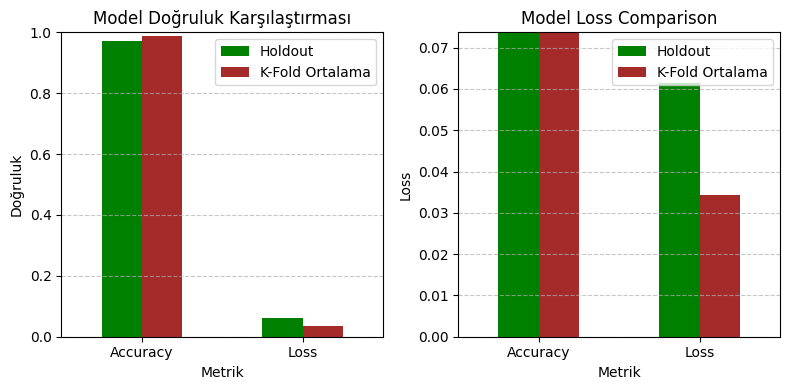

In [23]:

single_split_loss, single_split_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)


metrics_data = {
    'Metrik': ['Accuracy', 'Loss'],
    'Holdout': [single_split_accuracy, single_split_loss],
    'K-Fold Ortalama': [np.mean(kfold_accuracy), np.mean(kfold_loss)]
}

df_metrics = pd.DataFrame(metrics_data)

print("\n--- Performance Comparison ---")
display(df_metrics)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))


df_metrics.plot(x='Metrik', y=['Holdout', 'K-Fold Ortalama'], kind='bar', ax=axes[0],color=['green', 'brown'])
axes[0].set_title('Model Doğruluk Karşılaştırması')
axes[0].set_ylabel('Doğruluk')
axes[0].set_ylim(0.0, 1.0)
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)


df_metrics.plot(x='Metrik', y=['Holdout', 'K-Fold Ortalama'], kind='bar', ax=axes[1], color=['green', 'brown'])
axes[1].set_title('Model Loss Comparison')
axes[1].set_ylabel('Loss')
axes[1].set_ylim(0.0, max(single_split_loss, np.mean(kfold_loss)) * 1.2)
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Tarımsal Karar Destek Sistemi

In [24]:
def tarimsal_karar_destek_sistemi(yeni_toprak_verisi, model, scaler, class_names, top_k=3, T=2.5, simulasyon_sayisi=20):
    feature_names = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
    toplam_olasiliklar = np.zeros(len(class_names))

    # Gerçek hayat sensör gürültü oranları
    gurultu_oranlari = np.array([3.0, 3.0, 3.0, 0.5, 2.0, 0.1, 5.0])

    # 1. Simülasyon Döngüsü (Monte Carlo)
    for _ in range(simulasyon_sayisi):
        gurultu = np.random.normal(0, gurultu_oranlari)
        gurultulu_veri = yeni_toprak_verisi + gurultu

        # Sınır kontrolleri
        gurultulu_veri[4] = np.clip(gurultulu_veri[4], 0, 100)
        gurultulu_veri[5] = np.clip(gurultulu_veri[5], 0, 14)

        df_temp = pd.DataFrame([gurultulu_veri], columns=feature_names)
        scaled_temp = scaler.transform(df_temp)

        # verbose=0 ile konsol temizliği sağlanır
        toplam_olasiliklar += model.predict(scaled_temp, verbose=0)[0]

    ortalama_olasiliklar = toplam_olasiliklar / simulasyon_sayisi

    # 2. Matematiksel Yumuşatma (Temperature Scaling)
    duzlesmis_olasilik = np.exp(np.log(ortalama_olasiliklar + 1e-9) / T)
    duzlesmis_olasilik /= np.sum(duzlesmis_olasilik)

    # 3. Sadece En Yüksek K Adet Değeri Seçme ve Sıralama
    en_iyi_indeksler = np.argsort(duzlesmis_olasilik)[::-1][:top_k]

    # 4. Çıktıyı DataFrame olarak hazırlama
    oneriler = []
    for i, index in enumerate(en_iyi_indeksler):
        urun_adi = class_names[index]
        olasilik = duzlesmis_olasilik[index] * 100
        oneriler.append({'Alternatif': f'{i+1}.', 'Mahsul': urun_adi.upper(), 'Uygunluk Olasılığı (%)': f'{olasilik:.2f}'})

    return pd.DataFrame(oneriler)

In [25]:
# ==============================================================================
# SENARYO 1: "Süper Tropikal" Geliştirilmiş Toprak
# Hedef: Jute (Jüt) ve Rice (Pirinç) ikilisini %40-%40 gibi başabaş yarıştırmak
# ==============================================================================
# Sırasıyla: [N, P, K, temperature, humidity, ph, rainfall]
ornek_tarla_tropikal = np.array([90.0, 50.0, 40.0, 25.5, 82.0, 6.4, 180.0])


# ==============================================================================
# SENARYO 2: "Zengin Kurakçıl / Baklagil" Geliştirilmiş Toprak
# Hedef: Mothbeans ve Kidneybeans çekişmesini korurken, Chickpea (Nohut) ve
#        Lentil (Mercimek) ikilisini de yüksek olasılıkla dahil etmek.
# ==============================================================================
# Sırasıyla: [N, P, K, temperature, humidity, ph, rainfall]
ornek_tarla_kurakcil = np.array([40.0, 50.0, 22.0, 25.0, 38.0, 6.6, 50.0])


# ==============================================================================
# SENARYO 3: "Premium Meyve Bahçesi" Geliştirilmiş Toprak
# Hedef: Apple (Elma) ve Grapes (Üzüm) arasındaki o %80-%19'luk makası daraltıp
#        ikisine de %40-%45 bandında şans vermek, Banana'yı da tetiklemek.
# ==============================================================================
# Sırasıyla: [N, P, K, temperature, humidity, ph, rainfall]
ornek_tarla_meyve = np.array([25.0, 125.0, 195.0, 23.0, 90.0, 6.1, 110.0])

## HoldOut Modeli ile Tarımsal Karar Destek Sistemi

In [26]:
class_names = list(le.classes_)

print("\n--- ORİJİNAL MODEL SONUÇLARI ---")
print("TROPİKAL")
display(tarimsal_karar_destek_sistemi(ornek_tarla_tropikal, model, scaler, class_names, top_k=4))
print("-"*50)
print("KURAKCİL")
display(tarimsal_karar_destek_sistemi(ornek_tarla_kurakcil, model, scaler, class_names , top_k=4))
print("-"*50)
print("MEYVE")
display(tarimsal_karar_destek_sistemi(ornek_tarla_meyve, model, scaler, class_names, top_k=4))


--- ORİJİNAL MODEL SONUÇLARI ---
TROPİKAL


,Alternatif,Mahsul,Uygunluk Olasılığı (%)
0,1.,JUTE,62.89
1,2.,RICE,30.49
2,3.,BANANA,1.36
3,4.,COFFEE,1.19


--------------------------------------------------
KURAKCİL


,Alternatif,Mahsul,Uygunluk Olasılığı (%)
0,1.,MOTHBEANS,56.24
1,2.,KIDNEYBEANS,27.21
2,3.,MAIZE,8.85
3,4.,MANGO,3.55


--------------------------------------------------
MEYVE


,Alternatif,Mahsul,Uygunluk Olasılığı (%)
0,1.,GRAPES,88.91
1,2.,APPLE,10.61
2,3.,PAPAYA,0.04
3,4.,POMEGRANATE,0.03


## K-Kat Çapraz Doğrulama Modeli ile Tarımsal Karar Destek Sistemi


In [27]:
print("\n--- K-FOLD İLE EĞİTİLMİŞ MODEL SONUÇLARI ---")

print("TROPİKAL")
display(tarimsal_karar_destek_sistemi(ornek_tarla_tropikal, model_kfold, scaler, class_names, top_k=4))
print("-"*50)
print("KURAKCİL")
display(tarimsal_karar_destek_sistemi(ornek_tarla_kurakcil, model_kfold, scaler, class_names , top_k=4))
print("-"*50)
print("MEYVE")
display(tarimsal_karar_destek_sistemi(ornek_tarla_meyve, model_kfold, scaler, class_names, top_k=4))


--- K-FOLD İLE EĞİTİLMİŞ MODEL SONUÇLARI ---
TROPİKAL


,Alternatif,Mahsul,Uygunluk Olasılığı (%)
0,1.,JUTE,63.65
1,2.,RICE,30.70
2,3.,PAPAYA,1.75
3,4.,BANANA,1.44


--------------------------------------------------
KURAKCİL


,Alternatif,Mahsul,Uygunluk Olasılığı (%)
0,1.,MOTHBEANS,52.15
1,2.,KIDNEYBEANS,38.16
2,3.,MANGO,3.13
3,4.,PIGEONPEAS,2.49


--------------------------------------------------
MEYVE


,Alternatif,Mahsul,Uygunluk Olasılığı (%)
0,1.,APPLE,87.51
1,2.,GRAPES,7.87
2,3.,PAPAYA,4.20
3,4.,CHICKPEA,0.02
